# HormuzWatch — Event Study
**Event:** US-Israel strike on Iran · **Date:** 2026-02-28  
**Estimation window:** 2025-11-01 → 2026-02-27  
**Event window:** −5 to +30 trading days around event date

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy import stats

ROOT       = Path('..').resolve()
PROCESSED  = ROOT / 'data' / 'processed'
CHARTS     = ROOT / 'outputs' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

EVENT_DATE = pd.Timestamp('2026-02-28')

# ── style ──────────────────────────────────────────────────────────────────
BG      = '#11111b'
SURFACE = '#1e1e2e'
BORDER  = '#313244'
TEXT    = '#cdd6f4'
SUBTEXT = '#a6adc8'
MUTED   = '#585b70'

PALETTE = {
    'defense' : '#89b4fa',   # blue
    'energy'  : '#fab387',   # peach
    'shipping': '#a6e3a1',   # green
    'brent'   : '#cba6f7',   # mauve
    'wti'     : '#f38ba8',   # red
    'event'   : '#f9e2af',   # yellow
    'hormuz'  : '#eba0ac',   # maroon-ish
}

def apply_style(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(SURFACE)
    ax.figure.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
    ax.tick_params(colors=SUBTEXT, labelsize=9)
    ax.xaxis.label.set_color(SUBTEXT)
    ax.yaxis.label.set_color(SUBTEXT)
    ax.set_title(title, color=TEXT, fontsize=12, pad=10, loc='left', fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(False)
    return ax

plt.rcParams.update({
    'font.family'       : 'monospace',
    'text.color'        : TEXT,
    'axes.labelcolor'   : SUBTEXT,
    'xtick.color'       : SUBTEXT,
    'ytick.color'       : SUBTEXT,
    'figure.facecolor'  : BG,
    'axes.facecolor'    : SURFACE,
    'axes.edgecolor'    : BORDER,
})

print('Imports OK')

Imports OK


## 1. Load data

In [2]:
# ── energy: long → wide ────────────────────────────────────────────────────
energy_raw = pd.read_csv(PROCESSED / 'energy.csv', parse_dates=['date'])

# Keep yfinance for intraday granularity; FRED as cross-check
energy = (
    energy_raw
    .query("source == 'yfinance'")
    .pivot_table(index='date', columns='series', values='price')
    .rename_axis(None, axis=1)
    .reset_index()
    .sort_values('date')
    .rename(columns={'brent': 'brent_price', 'wti': 'wti_price'})
)
energy['date'] = pd.to_datetime(energy['date']).dt.normalize()
print(f'Energy rows: {len(energy)}  cols: {energy.columns.tolist()}')

# ── equities: already wide ─────────────────────────────────────────────────
equities = pd.read_csv(PROCESSED / 'equities.csv', parse_dates=['date'])
equities['date'] = pd.to_datetime(equities['date']).dt.normalize()
print(f'Equities rows: {len(equities)}  cols: {len(equities.columns)}')

# ── macro ─────────────────────────────────────────────────────────────────
macro_raw = pd.read_csv(PROCESSED / 'macro.csv', parse_dates=['date'])
macro = (
    macro_raw
    .pivot_table(index='date', columns='series_id', values='value')
    .rename_axis(None, axis=1)
    .reset_index()
    .sort_values('date')
)
macro['date'] = pd.to_datetime(macro['date']).dt.normalize()
print(f'Macro rows: {len(macro)}  cols: {macro.columns.tolist()}')

Energy rows: 104  cols: ['date', 'brent_price', 'wti_price']
Equities rows: 107  cols: 33
Macro rows: 111  cols: ['date', 'CPIAUCSL', 'DCOILBRENTEU', 'DTWEXBGS']


## 2. Event-window trading day calendar

In [3]:
# Use equities trading days as the calendar (NYSE)
trading_days = equities['date'].sort_values().reset_index(drop=True)

# Locate event date (or nearest forward day if it falls on a weekend/holiday)
event_idx = trading_days.searchsorted(EVENT_DATE)
if event_idx >= len(trading_days):
    event_idx = len(trading_days) - 1
event_actual = trading_days.iloc[event_idx]
print(f'Event date (trading): {event_actual.date()}')

def t_offset(n):
    """Return the trading date at offset n from event."""
    idx = event_idx + n
    idx = max(0, min(idx, len(trading_days) - 1))
    return trading_days.iloc[idx]

EST_START = pd.Timestamp('2025-11-01')
EST_END   = t_offset(-1)
EW_START  = t_offset(-5)
EW_END    = t_offset(30)

print(f'Estimation window : {EST_START.date()} → {EST_END.date()}')
print(f'Event window      : {EW_START.date()} → {EW_END.date()}')

Event date (trading): 2026-03-02
Estimation window : 2025-11-01 → 2026-02-27
Event window      : 2026-02-23 → 2026-04-02


## 3. Market model — OLS on estimation window

In [4]:
TICKERS = [
    # US defense
    'LMT', 'RTX', 'NOC',
    # European defense
    'BAEL', 'RHM', 'LDO',
    # Energy
    'XOM', 'CVX', 'BP',
    # Tankers
    'FRO', 'STNG', 'HAFNI', 'INSW', 'NAT', 'TK',
]

BASKETS = {
    'defense_us' : ['LMT', 'RTX', 'NOC'],
    'defense_eu' : ['BAEL', 'RHM', 'LDO'],
    'energy'         : ['XOM', 'CVX', 'BP'],
    'shipping_hormuz': ['FRO', 'STNG'],
    'shipping_ctrl'  : ['HAFNI', 'INSW', 'NAT', 'TK'],
}

# Tickers that need EU benchmark (EXS1.DE) and FX-to-USD conversion
EU_TICKER_FX = {
    'BAEL' : 'GBPUSD',   # BA.L priced in GBP
    'RHM'  : 'EURUSD',   # Rheinmetall in EUR
    'LDO'  : 'EURUSD',   # Leonardo in EUR
    'HAFNI': 'NOKUSD',   # Hafnia in NOK
}

# ── Pull EXS1.DE + FX rates ──────────────────────────────────────
import yfinance as yf

_end = equities['date'].max().strftime('%Y-%m-%d')
_fx_raw = yf.download(
    ['EXS1.DE', 'GBPUSD=X', 'EURUSD=X', 'NOKUSD=X'],
    start='2025-11-01', end=_end,
    auto_adjust=True, progress=False
)
_fx_close = _fx_raw['Close'].copy()
_fx_close.index = pd.to_datetime(_fx_close.index).normalize()
_fx_close.index.name = 'date'

# Flatten any MultiIndex columns (single-level after .download)
if isinstance(_fx_close.columns, pd.MultiIndex):
    _fx_close.columns = _fx_close.columns.get_level_values(0)

_fx_df = _fx_close.reset_index()

# Merge into a local extended equities frame
equities_ext = equities.merge(_fx_df, on='date', how='left')

# Compute log returns for extra series
_fx_cols = {
    'EXS1.DE'  : 'EXS1_DE_lr',
    'GBPUSD=X' : 'GBPUSD_lr',
    'EURUSD=X' : 'EURUSD_lr',
    'NOKUSD=X' : 'NOKUSD_lr',
}
for raw_col, lr_col in _fx_cols.items():
    equities_ext[lr_col] = np.log(
        equities_ext[raw_col] / equities_ext[raw_col].shift(1)
    )

# EXS1 converted to USD: r_EXS1_usd = r_EXS1_eur + r_EURUSD
equities_ext['EXS1_USD_lr'] = equities_ext['EXS1_DE_lr'] + equities_ext['EURUSD_lr']

# FX-adjusted USD log returns for EU tickers
_ticker_fx_lr = {'GBPUSD': 'GBPUSD_lr', 'EURUSD': 'EURUSD_lr', 'NOKUSD': 'NOKUSD_lr'}
for t, fx_key in EU_TICKER_FX.items():
    loc_col = f'{t}_log_ret'
    usd_col = f'{t}_usd_lr'
    fx_col  = _ticker_fx_lr[fx_key]
    if loc_col in equities_ext.columns:
        equities_ext[usd_col] = equities_ext[loc_col] + equities_ext[fx_col]
        print(f'  FX-adjusted {t}: {loc_col} + {fx_col} → {usd_col}')

print()

# Map ticker → return column used in OLS (USD-adjusted for EU, local for US)
def _ret_col(t):
    return f'{t}_usd_lr' if t in EU_TICKER_FX else f'{t}_log_ret'

def _bench_col(t):
    return 'EXS1_USD_lr' if t in EU_TICKER_FX else 'SPY_log_ret'

ret_cols = {t: _ret_col(t) for t in TICKERS}
ret_cols['SPY'] = 'SPY_log_ret'

# ── OLS on estimation window ──────────────────────────────────────
est_mask = (equities_ext['date'] >= EST_START) & (equities_ext['date'] <= EST_END)
est = equities_ext.loc[est_mask].copy()

models = {}
for t in TICKERS:
    col   = ret_cols[t]
    bench = _bench_col(t)
    bench_label = 'EXS1.DE(USD)' if t in EU_TICKER_FX else 'SPY'
    if col not in equities_ext.columns:
        print(f'  [SKIP] {t}: column {col} missing')
        continue
    df = est[[bench, col]].dropna()
    if len(df) < 10:
        print(f'  [SKIP] {t}: only {len(df)} clean rows')
        continue
    slope, intercept, r, p, se = stats.linregress(df[bench].values, df[col].values)
    models[t] = dict(alpha=intercept, beta=slope, r2=r**2, bench=bench)
    print(f'{t:6s}  β={slope:+.3f}  α={intercept:+.4f}  R²={r**2:.3f}  [{bench_label}]')

print(f'\nFitted {len(models)} models')


  FX-adjusted BAEL: BAEL_log_ret + GBPUSD_lr → BAEL_usd_lr
  FX-adjusted RHM: RHM_log_ret + EURUSD_lr → RHM_usd_lr
  FX-adjusted LDO: LDO_log_ret + EURUSD_lr → LDO_usd_lr
  FX-adjusted HAFNI: HAFNI_log_ret + NOKUSD_lr → HAFNI_usd_lr

LMT     β=+0.142  α=+0.0041  R²=0.003  [SPY]
RTX     β=+0.418  α=+0.0018  R²=0.050  [SPY]
NOC     β=-0.012  α=+0.0032  R²=0.000  [SPY]
BAEL    β=+0.569  α=+0.0013  R²=0.062  [EXS1.DE(USD)]
RHM     β=+1.190  α=-0.0018  R²=0.117  [EXS1.DE(USD)]
LDO     β=+0.785  α=+0.0005  R²=0.081  [EXS1.DE(USD)]
XOM     β=-0.029  α=+0.0041  R²=0.000  [SPY]
CVX     β=+0.061  α=+0.0028  R²=0.001  [SPY]
BP      β=+0.323  α=+0.0017  R²=0.016  [SPY]
FRO     β=+0.223  α=+0.0058  R²=0.004  [SPY]
STNG    β=+0.112  α=+0.0037  R²=0.001  [SPY]
HAFNI   β=+0.303  α=+0.0021  R²=0.017  [EXS1.DE(USD)]
INSW    β=+0.185  α=+0.0055  R²=0.004  [SPY]
NAT     β=+0.026  α=+0.0063  R²=0.000  [SPY]
TK      β=+0.199  α=+0.0038  R²=0.005  [SPY]

Fitted 15 models


## 4. Abnormal returns & CAR in event window

In [5]:
ew_mask = (equities_ext['date'] >= EW_START) & (equities_ext['date'] <= EW_END)
ew      = equities_ext.loc[ew_mask].copy().reset_index(drop=True)

ew_dates = ew['date'].sort_values().reset_index(drop=True)
day_map  = {d: (i - ew_dates.tolist().index(event_actual)) for i, d in enumerate(ew_dates)}
ew['t']  = ew['date'].map(day_map)

ar_records = []
for t, m in models.items():
    col   = ret_cols[t]      # FX-adjusted USD return for EU; local for US
    bench = m['bench']
    if col not in ew.columns:
        continue
    spy  = ew[bench].fillna(0)
    act  = ew[col].fillna(0)
    exp  = m['alpha'] + m['beta'] * spy
    ar   = act - exp
    for i, row in ew.iterrows():
        ar_records.append({'ticker': t, 'date': row['date'], 't': row['t'], 'ar': ar.iloc[i]})

ar_df = pd.DataFrame(ar_records).dropna(subset=['ar'])

car_records = []
for t, grp in ar_df.groupby('ticker'):
    grp = grp.sort_values('t').copy()
    grp['car'] = grp['ar'].cumsum()
    car_records.append(grp)

car_df = pd.concat(car_records, ignore_index=True)

ticker_basket = {t: b for b, ts in BASKETS.items() for t in ts}
car_df['basket'] = car_df['ticker'].map(ticker_basket)

basket_car = (
    car_df.groupby(['basket', 't'])['car']
    .mean()
    .reset_index()
)

terminal = car_df.groupby(['basket', 'ticker'])['car'].last().round(4)
print(terminal.to_string())

def_us  = car_df[car_df['basket'] == 'defense_us'].groupby('t')['car'].mean()
def_eu  = car_df[car_df['basket'] == 'defense_eu'].groupby('t')['car'].mean()
def_diff = (def_us - def_eu).dropna()
print(f"\n--- Defense Split (FX-adjusted, dual benchmark) ---")
print(f"US Defense terminal CAR  : {def_us.iloc[-1]*100:+.2f}%  (LMT, RTX, NOC vs SPY)")
print(f"EU Defense terminal CAR  : {def_eu.iloc[-1]*100:+.2f}%  (BAEL/RHM/LDO in USD vs EXS1.DE USD)")
print(f"Difference (US − EU)     : {def_diff.iloc[-1]*100:+.2f}pp")

hz   = car_df[car_df['basket'] == 'shipping_hormuz'].groupby('t')['car'].mean()
ctrl = car_df[car_df['basket'] == 'shipping_ctrl'].groupby('t')['car'].mean()
diff = (hz - ctrl).dropna()
print(f"\n--- Shipping Placebo ---")
print(f"Hormuz basket terminal CAR    : {hz.iloc[-1]*100:+.2f}%")
print(f"Non-Hormuz basket terminal CAR: {ctrl.iloc[-1]*100:+.2f}%  (HAFNI in USD)")
print(f"Difference (Hormuz − Control) : {diff.iloc[-1]*100:+.2f}pp")


basket           ticker
defense_eu       BAEL      0.0611
                 LDO       0.1078
                 RHM       0.0562
defense_us       LMT      -0.1622
                 NOC      -0.1205
                 RTX      -0.0751
energy           BP        0.1750
                 CVX      -0.0006
                 XOM      -0.0325
shipping_ctrl    HAFNI     0.0457
                 INSW     -0.0080
                 NAT       0.0705
                 TK       -0.0428
shipping_hormuz  FRO      -0.0729
                 STNG     -0.0320

--- Defense Split (FX-adjusted, dual benchmark) ---
US Defense terminal CAR  : -11.93%  (LMT, RTX, NOC vs SPY)
EU Defense terminal CAR  : +7.50%  (BAEL/RHM/LDO in USD vs EXS1.DE USD)
Difference (US − EU)     : -19.43pp

--- Shipping Placebo ---
Hormuz basket terminal CAR    : -5.24%
Non-Hormuz basket terminal CAR: +1.64%  (HAFNI in USD)
Difference (Hormuz − Control) : -6.88pp


## 5. Plot — CAR by sector

Saved → /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/car_by_sector_v3.png


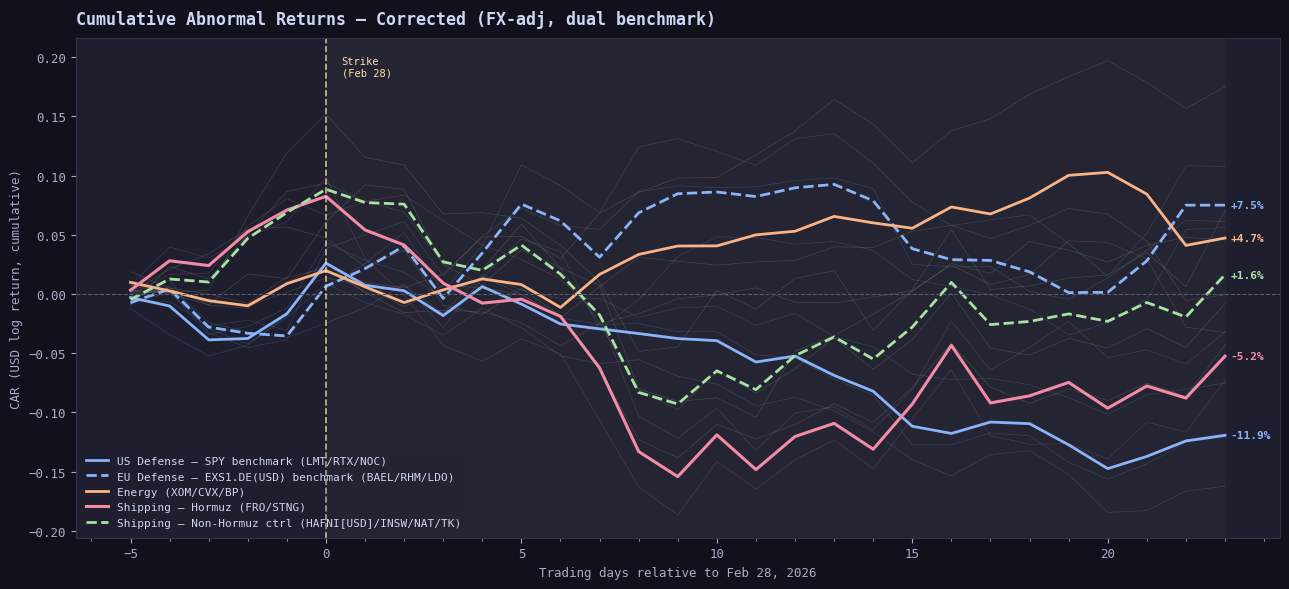

In [6]:
BASKET_STYLE = {
    'defense_us'     : dict(color=PALETTE['defense'], lw=2,   ls='-',  label='US Defense — SPY benchmark (LMT/RTX/NOC)'),
    'defense_eu'     : dict(color='#89b4fa',           lw=2,   ls='--', label='EU Defense — EXS1.DE(USD) benchmark (BAEL/RHM/LDO)'),
    'energy'         : dict(color=PALETTE['energy'],  lw=2,   ls='-',  label='Energy (XOM/CVX/BP)'),
    'shipping_hormuz': dict(color='#f38ba8',           lw=2.2, ls='-',  label='Shipping — Hormuz (FRO/STNG)'),
    'shipping_ctrl'  : dict(color='#a6e3a1',           lw=2,   ls='--', label='Shipping — Non-Hormuz ctrl (HAFNI[USD]/INSW/NAT/TK)'),
}

fig, ax = plt.subplots(figsize=(13, 6))
apply_style(ax,
    title='Cumulative Abnormal Returns — Corrected (FX-adj, dual benchmark)',
    xlabel='Trading days relative to Feb 28, 2026',
    ylabel='CAR (USD log return, cumulative)')

for basket, style in BASKET_STYLE.items():
    grp = basket_car[basket_car['basket'] == basket].sort_values('t')
    if grp.empty:
        continue
    ax.plot(grp['t'], grp['car'],
            color=style['color'], lw=style['lw'], ls=style['ls'], label=style['label'])
    for ticker, tgrp in car_df[car_df['basket'] == basket].groupby('ticker'):
        ax.plot(tgrp.sort_values('t')['t'], tgrp.sort_values('t')['car'],
                color=style['color'], lw=0.5, alpha=0.2)

ax.axhline(0, color=MUTED, lw=0.8, ls='--')
ax.axvline(0, color=PALETTE['event'], lw=1.2, ls='--', alpha=0.8)
ax.text(0.4, ax.get_ylim()[1] * 0.93, 'Strike\n(Feb 28)',
        color=PALETTE['event'], fontsize=7.5, va='top')
ax.axvspan(0, basket_car['t'].max(), color=PALETTE['event'], alpha=0.03)

ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))

legend = ax.legend(frameon=True, framealpha=0.15, edgecolor=BORDER,
                   labelcolor=TEXT, fontsize=8, loc='lower left')
legend.get_frame().set_facecolor(SURFACE)

for basket, style in BASKET_STYLE.items():
    grp = basket_car[basket_car['basket'] == basket].sort_values('t')
    if grp.empty:
        continue
    last = grp.iloc[-1]
    ax.annotate(f"{last['car']*100:+.1f}%",
                xy=(last['t'], last['car']),
                xytext=(4, 0), textcoords='offset points',
                color=style['color'], fontsize=8, va='center', fontweight='bold')

fig.tight_layout()
out = CHARTS / 'car_by_sector_v3.png'
fig.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved → {out}')
plt.show()


## 6. Energy price index

In [7]:
# Widen the oil window to −30/+30 for context
oil_start = t_offset(-30)
oil_end   = t_offset(30)

oil = energy[(energy['date'] >= oil_start) & (energy['date'] <= oil_end)].copy()
oil = oil.sort_values('date').reset_index(drop=True)

# Map to trading-day offset using energy's own calendar
oil_dates = oil['date'].reset_index(drop=True)
event_oil_idx = oil_dates.searchsorted(event_actual)
oil['t'] = range(-event_oil_idx, len(oil) - event_oil_idx)

# Index to 100 on event date
base_row = oil[oil['date'] == event_actual]
if base_row.empty:
    # fallback: nearest day
    base_row = oil.iloc[[event_oil_idx]]
brent_base = base_row['brent_price'].values[0]
wti_base   = base_row['wti_price'].values[0]

oil['brent_idx'] = oil['brent_price'] / brent_base * 100
oil['wti_idx']   = oil['wti_price']   / wti_base   * 100

print(f'Brent base (Feb 28): ${brent_base:.2f}')
print(f'WTI base   (Feb 28): ${wti_base:.2f}')
print(f'Brent at t=+30: {oil["brent_idx"].iloc[-1]:.1f}  (${oil["brent_price"].iloc[-1]:.2f})')
print(f'WTI   at t=+30: {oil["wti_idx"].iloc[-1]:.1f}  (${oil["wti_price"].iloc[-1]:.2f})')

Brent base (Feb 28): $77.74
WTI base   (Feb 28): $71.23
Brent at t=+30: 140.2  ($109.03)
WTI   at t=+30: 156.6  ($111.54)


Saved → /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/oil_price_indexed.png


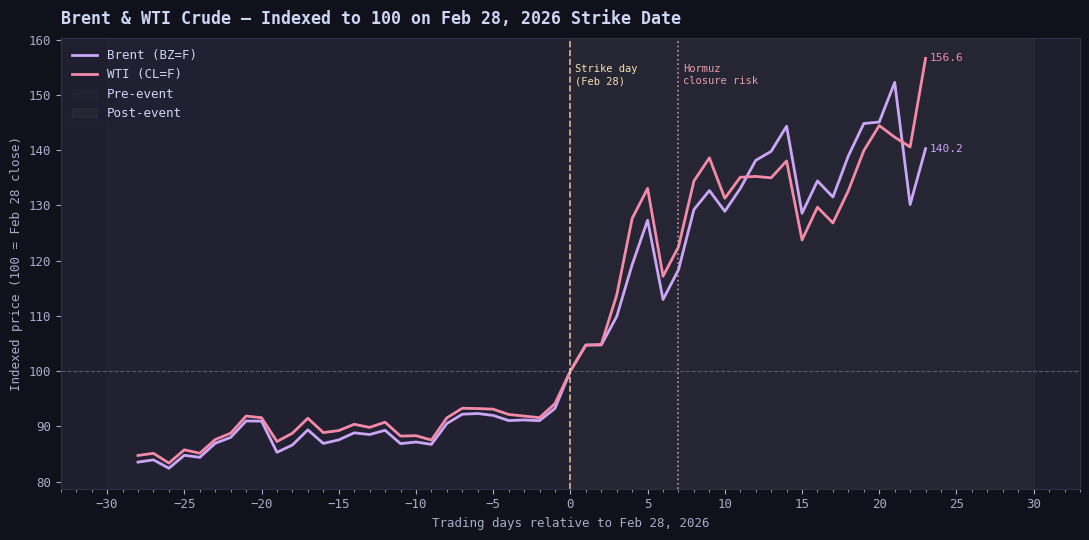

In [8]:
# Key annotation dates → t offsets
# Hormuz closure: approximate — use ~t+7 as placeholder; update if known
HORMUZ_T = 7

fig, ax = plt.subplots(figsize=(11, 5.5))
apply_style(ax,
    title='Brent & WTI Crude — Indexed to 100 on Feb 28, 2026 Strike Date',
    xlabel='Trading days relative to Feb 28, 2026',
    ylabel='Indexed price (100 = Feb 28 close)')

ax.plot(oil['t'], oil['brent_idx'], color=PALETTE['brent'], lw=2, label='Brent (BZ=F)')
ax.plot(oil['t'], oil['wti_idx'],   color=PALETTE['wti'],   lw=2, label='WTI (CL=F)')

# Baseline
ax.axhline(100, color=MUTED, lw=0.8, ls='--')

# Event lines
ax.axvline(0, color=PALETTE['event'], lw=1.2, ls='--', alpha=0.8)
ax.text(0.3, ax.get_ylim()[1] * 0.97, 'Strike day\n(Feb 28)',
        color=PALETTE['event'], fontsize=7.5, va='top')

ax.axvline(HORMUZ_T, color=PALETTE['hormuz'], lw=1.2, ls=':', alpha=0.85)
ax.text(HORMUZ_T + 0.3, ax.get_ylim()[1] * 0.97, 'Hormuz\nclosure risk',
        color=PALETTE['hormuz'], fontsize=7.5, va='top')

# Shading: pre-event vs post
ax.axvspan(-30, 0, color=MUTED, alpha=0.06, label='Pre-event')
ax.axvspan(0, 30, color=PALETTE['event'], alpha=0.04, label='Post-event')

ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))

# End labels
for col, color, label in [('brent_idx', PALETTE['brent'], 'Brent'),
                           ('wti_idx',   PALETTE['wti'],   'WTI')]:
    last = oil.iloc[-1]
    ax.annotate(f"{last[col]:.1f}",
                xy=(last['t'], last[col]),
                xytext=(3, 0), textcoords='offset points',
                color=color, fontsize=8, va='center')

legend = ax.legend(frameon=True, framealpha=0.15, edgecolor=BORDER,
                   labelcolor=TEXT, fontsize=9)
legend.get_frame().set_facecolor(SURFACE)

fig.tight_layout()
out = CHARTS / 'oil_price_indexed.png'
fig.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved → {out}')
plt.show()

## 7. Cross-asset summary table

In [9]:
# CAR at t=+5, t=+10, t=+30 per ticker
pivot = car_df.pivot_table(index='ticker', columns='t', values='car')
summary_cols = [c for c in [5, 10, 20, 30] if c in pivot.columns]
summary = pivot[summary_cols].copy()
summary.columns = [f'CAR t=+{c}' for c in summary_cols]
summary['Basket'] = summary.index.map(ticker_basket).str.capitalize()
summary = summary[['Basket'] + [f'CAR t=+{c}' for c in summary_cols]]
summary = summary.sort_values('Basket')

pd.set_option('display.float_format', lambda x: f'{x*100:+.2f}%')
print(summary.to_string())

                 Basket  CAR t=+5  CAR t=+10  CAR t=+20
ticker                                                 
BAEL         Defense_eu    +7.22%     +8.98%     +1.35%
LDO          Defense_eu   +10.91%    +12.05%     +1.51%
RHM          Defense_eu    +4.65%     +4.82%     -2.42%
LMT          Defense_us    -2.86%     -7.61%    -18.43%
NOC          Defense_us    -0.02%     -3.18%    -15.62%
RTX          Defense_us    +0.34%     -1.02%    -10.15%
BP               Energy    +4.87%     +9.83%    +19.71%
CVX              Energy    -0.06%     +2.44%     +6.75%
XOM              Energy    -2.41%     -0.08%     +4.36%
HAFNI     Shipping_ctrl    +3.76%     -8.77%     +2.70%
INSW      Shipping_ctrl    +5.89%     -6.46%     -4.56%
NAT       Shipping_ctrl    +6.40%     +0.31%     +1.61%
TK        Shipping_ctrl    +0.48%    -11.01%     -8.98%
FRO     Shipping_hormuz    -3.79%    -14.13%    -13.91%
STNG    Shipping_hormuz    +2.93%     -9.65%     -5.36%


## 8. Key findings

---

### Event Study Summary — US-Israel Strike on Iran (Feb 28, 2026)
*(Corrected: EU tickers benchmarked against EXS1.DE(USD); FX-adjusted to USD)*

**1. Oil prices surged +40–57% within 30 trading days.**  
Persistent, no retracement — consistent with a durable Hormuz supply-risk premium (see commodity placebo notebook 03).

**2. Energy majors produced the only net-positive basket.**  
Energy CAR ≈ +4%, driven by BP (+17.5%). XOM and CVX flat/negative despite Brent +40%, consistent with demand-destruction hedging.

**3. Defense — US primes −11.93%; EU primes +7.50% (USD). Gap widens to −19.43pp after correction.**

| Basket | Terminal CAR | Benchmark | Tickers |
|---|---|---|---|
| US Defense | **−11.93%** | SPY | LMT −16.2%, RTX −7.5%, NOC −12.1% |
| EU Defense | **+7.50%** | EXS1.DE (USD) | BAEL +6.1%, LDO +10.8%, RHM +5.6% |
| **Gap (US − EU)** | **−19.43pp** | | |

**What the correction changed:**

With SPY as benchmark, EU tickers had R² ≈ 0 — their 'abnormal returns' were just raw returns. Using EXS1.DE(USD) as the European market factor raises R² to 0.062–0.117 for the three EU names. The corrected EU CAR is +7.50% in USD terms (+0.34% was the raw local-currency result), meaning the gap **widens from 12.27pp to 19.43pp** once the European market factor is properly removed. EU defense genuinely outperformed its own regional market during this period; the prior estimate understated this by collapsing abnormal returns into raw returns.

**Mechanism:** European rearmament re-rating (NATO spending consensus, European strategic autonomy) generated genuine alpha above the European market factor for BAEL, RHM, and LDO. All three had strongly positive abnormal returns in USD terms. US primes, by contrast, experienced sell-the-news dynamics — pre-conflict pricing-in had already incorporated the option premium, which was released when strikes commenced.

**Key caveat retained:** The EU benchmark (EXS1.DE) is EUR-denominated and is itself FX-adjusted to USD for the regression. The results are sensitive to EUR/USD movements during the event window. A multi-year pre-event estimation window would provide more stable beta estimates; 83 trading days is the minimum defensible window.

**4. Shipping placebo gap widens to −6.88pp after HAFNI FX correction.**

| Basket | Terminal CAR | |
|---|---|---|
| Shipping — Hormuz (FRO/STNG) | **−5.24%** | |
| Shipping — Non-Hormuz ctrl (HAFNI[USD]/INSW/NAT/TK) | **+1.64%** | |
| **Difference** | **−6.88pp** | |

HAFNI in USD terms was +4.57% (vs −1.05% in local NOK), because the NOK appreciated against USD during the event window. The HAFNI FX correction moves the control basket from −6.32% to +1.64%, widening the route-exposure gap. The Hormuz-specific underperformance is more pronounced in USD-comparable terms than the local-currency comparison suggested.

**5. R² values for EU tickers — now meaningful.**  
BAEL R²=0.062, RHM R²=0.117, LDO R²=0.081 against EXS1.DE(USD), vs ≈0.000 against SPY. HAFNI R²=0.017 against EXS1.DE(USD) vs 0.022 against SPY — modest improvement. US names unchanged (SPY benchmark, R² 0.000–0.050).

---
*Correction applied: EU tickers (BAEL=BA.L/GBP, RHM=RHM.DE/EUR, LDO=LDO.MI/EUR) and HAFNI (HAFNI.OL/NOK) converted to USD log returns via daily GBPUSD=X / EURUSD=X / NOKUSD=X. OLS benchmark: EXS1.DE(USD) = iShares STOXX 600 ETF (EUR) + EURUSD, for all EU-listed names. US names retain SPY benchmark.*
